<a href="https://colab.research.google.com/github/ItserX/dsp-seminars/blob/kondakov-lab6/6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическое занятие №6: Синтез цифровых фильтров (КИХ и БИХ)

## Часть 1. Синтез КИХ-фильтров методом окон

### Задание 1.1. Проектирование ФНЧ с разными окнами
Спроектируйте КИХ-ФНЧ с частотой среза 200 Гц (частота дискретизации 1000 Гц), длина фильтра 51 отсчёт. Используйте окна:
- прямоугольное,
- Ханна,
- Хемминга,
- Блэкмана.

Постройте на одном графике АЧХ (в дБ) всех четырёх фильтров. Сравните:
- крутизну среза,
- уровень пульсаций в полосе пропускания и заграждения,
- ширину переходной полосы.


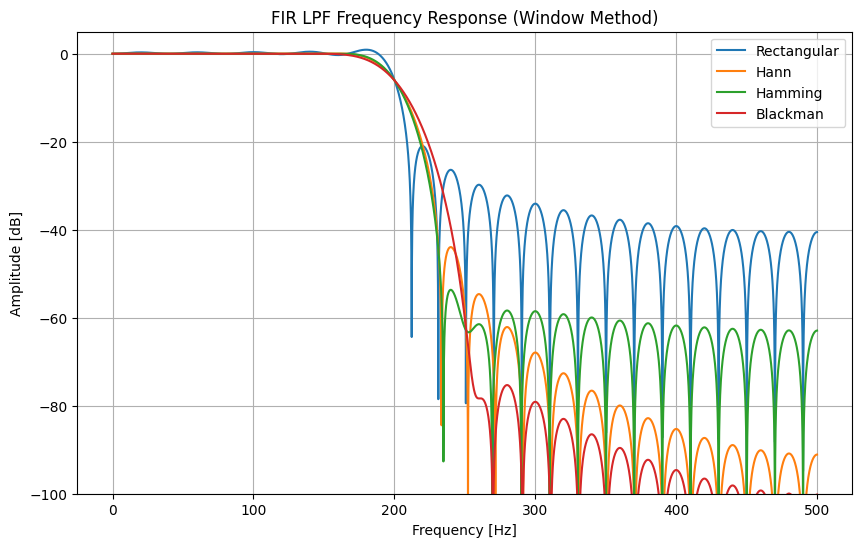

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

fs = 1000
fc = 200
numtaps = 51
nyq = 0.5 * fs
wc = fc / nyq

windows = ['boxcar', 'hann', 'hamming', 'blackman']
labels = ['Rectangular', 'Hann', 'Hamming', 'Blackman']

plt.figure(figsize=(10, 6))

for win, label in zip(windows, labels):
    h = signal.firwin(numtaps, wc, window=win)
    w, h_freq = signal.freqz(h, worN=8000)
    plt.plot(w * nyq / np.pi, 20 * np.log10(np.abs(h_freq)), label=label)

plt.title('FIR LPF Frequency Response (Window Method)')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Amplitude [dB]')
plt.ylim([-100, 5])
plt.grid(True)
plt.legend()
plt.show()

**Вопросы:** Какое окно обеспечивает наилучшее подавление в полосе заграждения? Какое – самую крутую переходную полосу? Как это связано с формой окна?

Наилучшее подавление в полосе заграждения обеспечивает окно Блэкмана. Самую крутую переходную полосу обеспечивает прямоугольное окно. Это связано с формой окна: чем более плавно окно спадает к краям во временной области, тем шире главный лепесток в частотной области и тем ниже уровень боковых лепестков.

### Задание 1.2. Влияние длины фильтра
Для окна Хемминга спроектируйте ФНЧ с fc=200 Гц, fs=1000 Гц, с длинами 21, 51, 101. Постройте АЧХ на одном графике.


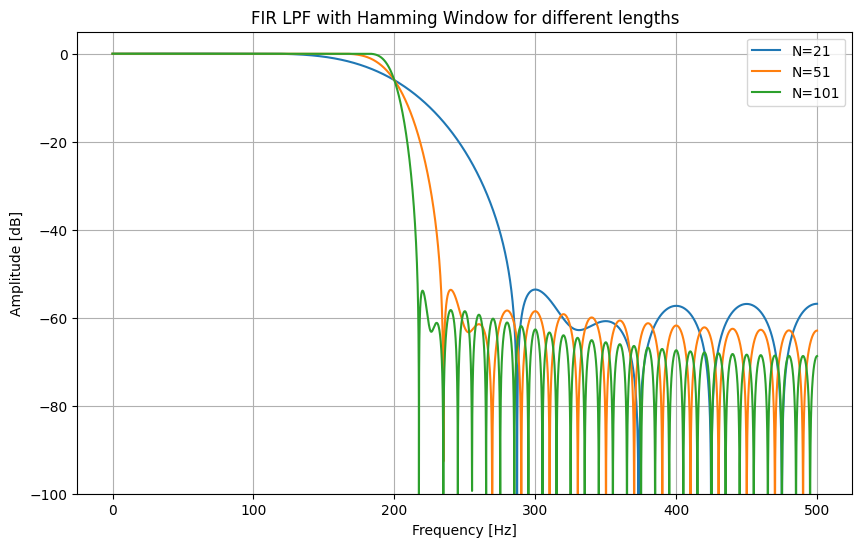

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

fs = 1000
fc = 200
nyq = 0.5 * fs
wc = fc / nyq
lengths = [21, 51, 101]

plt.figure(figsize=(10, 6))
for numtaps in lengths:
    h = signal.firwin(numtaps, wc, window='hamming')
    w, h_freq = signal.freqz(h, worN=8000)
    plt.plot(w * nyq / np.pi, 20 * np.log10(np.abs(h_freq)), label=f'N={numtaps}')

plt.title('FIR LPF with Hamming Window for different lengths')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Amplitude [dB]')
plt.ylim([-100, 5])
plt.grid(True)
plt.legend()
plt.show()

**Вопрос:** Как увеличение длины влияет на крутизну среза и на уровень боковых лепестков?

Увеличение длины фильтра увеличивает крутизну среза. Уровень боковых лепестков практически не зависит от длины фильтра, а определяется в основном типом используемого окна.


### Задание 1.3. Синтез ФВЧ и полосового фильтра методом окон
Используя тот же оконный метод, спроектируйте:
- ФВЧ с fc=200 Гц (длина 51, окно Хемминга);
- полосовой фильтр с полосой пропускания 200–300 Гц (длина 51, окно Хемминга).

Постройте АЧХ обоих фильтров.


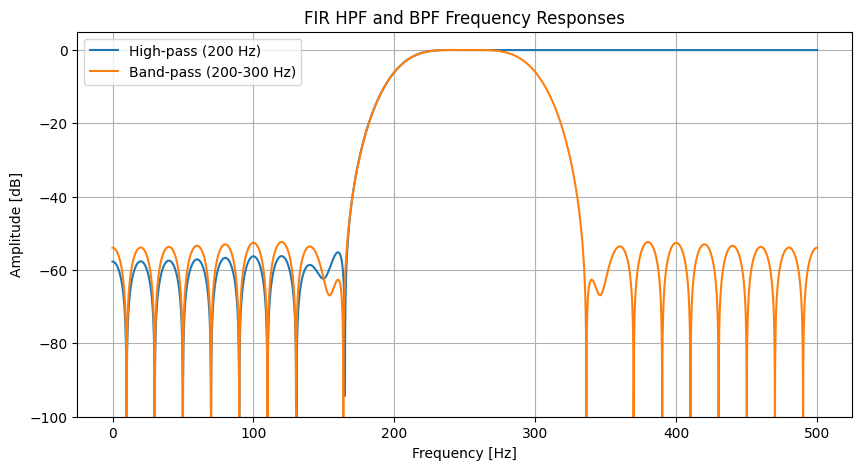

In [3]:
numtaps = 51
fc_hp = 200
bp = [200, 300]

# HPF
h_hp = signal.firwin(numtaps, fc_hp / nyq, pass_zero=False, window='hamming')
# BPF
h_bp = signal.firwin(numtaps, [f / nyq for f in bp], pass_zero=False, window='hamming')

w, H_hp = signal.freqz(h_hp, worN=8000)
w, H_bp = signal.freqz(h_bp, worN=8000)

plt.figure(figsize=(10, 5))
plt.plot(w * nyq / np.pi, 20 * np.log10(np.abs(H_hp) + 1e-12), label='High-pass (200 Hz)')
plt.plot(w * nyq / np.pi, 20 * np.log10(np.abs(H_bp) + 1e-12), label='Band-pass (200-300 Hz)')
plt.title('FIR HPF and BPF Frequency Responses')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Amplitude [dB]')
plt.ylim([-100, 5])
plt.grid(True)
plt.legend()
plt.show()

Подайте на спроектированные фильтры сигнал: сумма синусоид 100, 250 и 350 Гц (амплитуды 1, 0.8, 0.6). Постройте спектры до и после фильтрации (в логарифмическом масштабе).

/tmp/ipykernel_10732/69343166.py:8: UserWarning: nperseg=1024 is greater than signal length max(len(x), len(y)) = 1000, using nperseg = 1000
  f, Pxx = signal.welch(s, fs, nperseg=1024)


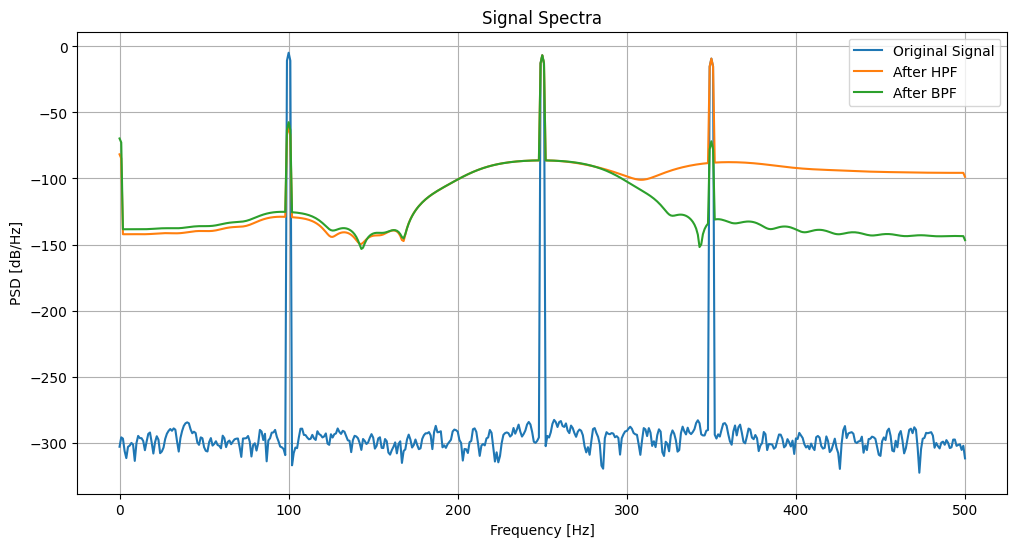

In [4]:
t = np.arange(0, 1, 1/fs)
sig_13 = 1.0 * np.sin(2 * np.pi * 100 * t) + 0.8 * np.sin(2 * np.pi * 250 * t) + 0.6 * np.sin(2 * np.pi * 350 * t)

filtered_hp = signal.lfilter(h_hp, 1, sig_13)
filtered_bp = signal.lfilter(h_bp, 1, sig_13)

def plot_spectrum(s, title):
    f, Pxx = signal.welch(s, fs, nperseg=1024)
    plt.plot(f, 10 * np.log10(Pxx), label=title)

plt.figure(figsize=(12, 6))
plot_spectrum(sig_13, 'Original Signal')
plot_spectrum(filtered_hp, 'After HPF')
plot_spectrum(filtered_bp, 'After BPF')
plt.title('Signal Spectra')
plt.xlabel('Frequency [Hz]')
plt.ylabel('PSD [dB/Hz]')
plt.grid(True)
plt.legend()
plt.show()

**Вопрос:** Объясните полученные результаты.

В исходном сигнале присутствуют пики на частотах 100, 250 и 350 Гц.
- ФВЧ (частота среза 200 Гц) подавляет компоненту 100 Гц, оставляя частоты 250 Гц и 350 Гц.
- Полосовой фильтр (200-300 Гц) подавляет как 100 Гц, так и 350 Гц, оставляя только компоненту 250 Гц.
Спектры после фильтрации подтверждают подавление амплитуд соответствующих частот согласно АЧХ спроектированных фильтров.

## Часть 2. Равноволновой синтез КИХ-фильтров (Паркса–МакКлеллана)

### Задание 2.1. Проектирование оптимального ФНЧ
Используя `signal.remez`, спроектируйте ФНЧ с параметрами:
- частота дискретизации 1000 Гц,
- полоса пропускания 0–150 Гц,
- полоса заграждения 250–500 Гц,
- длина фильтра 21.

Постройте АЧХ (в линейном и логарифмическом масштабах) и сравните её с АЧХ КИХ-фильтра, полученного методом окон (окно Хемминга, та же длина, fc=200 Гц).

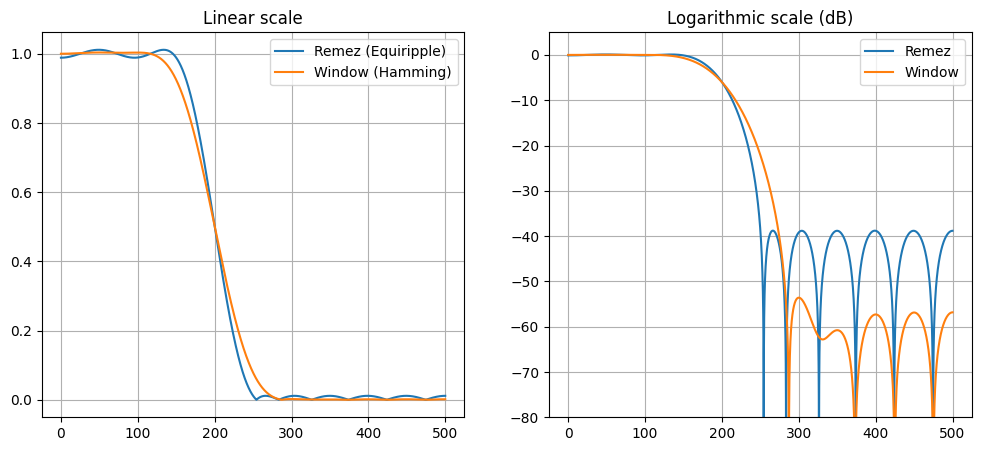

In [5]:
numtaps_2 = 21
bands = [0, 150, 250, 500]
desired = [1, 0]

h_remez = signal.remez(numtaps_2, bands, desired, fs=fs)
h_win = signal.firwin(numtaps_2, 200 / (0.5 * fs), window='hamming')

w_r, H_r = signal.freqz(h_remez, worN=8000)
w_w, H_w = signal.freqz(h_win, worN=8000)

freqs = w_r * 0.5 * fs / np.pi

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(freqs, np.abs(H_r), label='Remez (Equiripple)')
plt.plot(freqs, np.abs(H_w), label='Window (Hamming)')
plt.title('Linear scale')
plt.grid(True); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(freqs, 20 * np.log10(np.abs(H_r) + 1e-12), label='Remez')
plt.plot(freqs, 20 * np.log10(np.abs(H_w) + 1e-12), label='Window')
plt.title('Logarithmic scale (dB)')
plt.ylim([-80, 5])
plt.grid(True); plt.legend()
plt.show()


**Вопросы:** Какой фильтр имеет более крутой срез? Каковы пульсации в полосе пропускания?

Фильтр, спроектированный алгоритмом Паркса-МакКлеллана, имеет более крутой срез по сравнению с методом окон при той же длине фильтра. Однако у него присутствуют заметные равноволновые пульсации в полосе пропускания, в то время как фильтр методом окон имеет монотонный спад в полосе пропускания без пульсаций.

### Задание 2.2. Зависимость от ширины переходной полосы

Поменяйте верхнюю частоту полосы пропускания и нижнюю частоту полосы заграждения так, чтобы их среднее оставалось равным 200 Гц. Постройте АЧХ получившегося фильтра. Подберите ширину переходной области (разности нижней частоты полосы заграждения и верхней частоты полосы пропускания) так, чтобы уровень подавления в полосе заграждения у равноволнового фильтра совпал с оконным фильтром Хемминга.


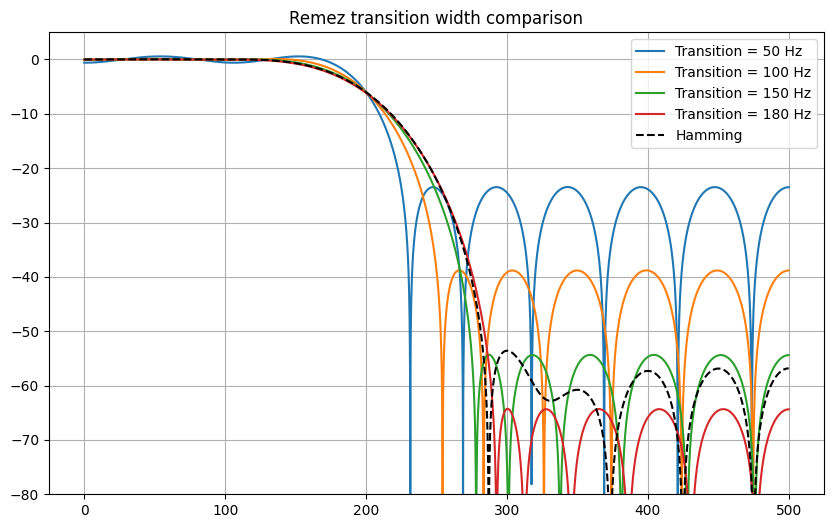

In [6]:
h_win_2 = signal.firwin(21, 200 / (0.5 * fs), window='hamming')
_, H_w_2 = signal.freqz(h_win_2, worN=8000)

plt.figure(figsize=(10, 6))
deltas = [50, 100, 150, 180]
for d in deltas:
    pass_end = 200 - d/2
    stop_start = 200 + d/2
    bands_d = [0, pass_end, stop_start, 500]
    h_r_d = signal.remez(21, bands_d, [1, 0], fs=fs)
    w, H_r_d = signal.freqz(h_r_d, worN=8000)
    plt.plot(w * 0.5 * fs / np.pi, 20 * np.log10(np.abs(H_r_d) + 1e-12), label=f'Transition = {d} Hz')

plt.plot(w * 0.5 * fs / np.pi, 20 * np.log10(np.abs(H_w_2) + 1e-12), 'k--', label='Hamming')
plt.title('Remez transition width comparison')
plt.ylim([-80, 5])
plt.grid(True); plt.legend()
plt.show()

**Вопрос:** При какой ширине переходной области уровень подавления в полосе заграждения у равноволнового фильтра совпал с оконным фильтром Хемминга?

Уровень подавления боковых лепестков окна Хемминга составляет около -53 дБ. Чтобы достичь такого же подавления в полосе заграждения у равноволнового фильтра, требуется значительно расширить переходную полосу (ширина переходной области составляет примерно 170-180 Гц, например полоса пропускания до 110 Гц, а заграждения от 290 Гц).

### Задание 2.3. Управление весами
Для фильтра из задачи 2.1 измените весовые коэффициенты: задайте `weight=[1, 10]` (увеличить вес для полосы заграждения). Постройте новую АЧХ и сравните с предыдущей.


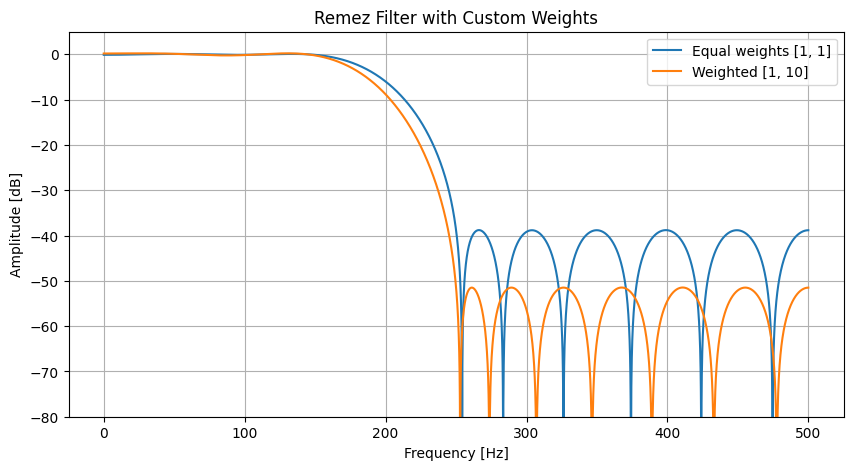

In [7]:
h_remez_equal = signal.remez(21, [0, 150, 250, 500], [1, 0], fs=fs)
h_remez_weighted = signal.remez(21, [0, 150, 250, 500], [1, 0], weight=[1, 10], fs=fs)

w, H_eq = signal.freqz(h_remez_equal, worN=8000)
w, H_wtd = signal.freqz(h_remez_weighted, worN=8000)

freqs = w * 0.5 * fs / np.pi

plt.figure(figsize=(10, 5))
plt.plot(freqs, 20 * np.log10(np.abs(H_eq) + 1e-12), label='Equal weights [1, 1]')
plt.plot(freqs, 20 * np.log10(np.abs(H_wtd) + 1e-12), label='Weighted [1, 10]')
plt.title('Remez Filter with Custom Weights')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Amplitude [dB]')
plt.ylim([-80, 5])
plt.grid(True)
plt.legend()
plt.show()

**Вопрос:** Как изменилось подавление в полосе заграждения и пульсации в полосе пропускания?

При увеличении веса для полосы заграждения подавление в полосе заграждения улучшилось (стало более глубоким, уровень пульсаций снизился). Однако ценой этого стало увеличение пульсаций в полосе пропускания, так как алгоритм Паркса-МакКлеллана перераспределил ошибку аппроксимации в соответствии с заданными весами.

### Задание 2.4. Сравнение КИХ-фильтров на реальном сигнале
Сгенерируйте сигнал: смесь синусоид 50 Гц, 120 Гц, 220 Гц (амплитуды 1, 0.7, 0.3) + белый шум (дисперсия 0.1), fs=1000 Гц. Пропустите этот сигнал через:
- КИХ-ФНЧ спроектированный методом окон (окно Хемминга, длина 51, fc=150 Гц);
- КИХ-ФНЧ спроектированный методом `remez` (длина 51, полоса пропускания 0–100 Гц, полоса заграждения 200–500 Гц).

Постройте спектры исходного и отфильтрованных сигналов в линейном и логарифмическом масштабе.


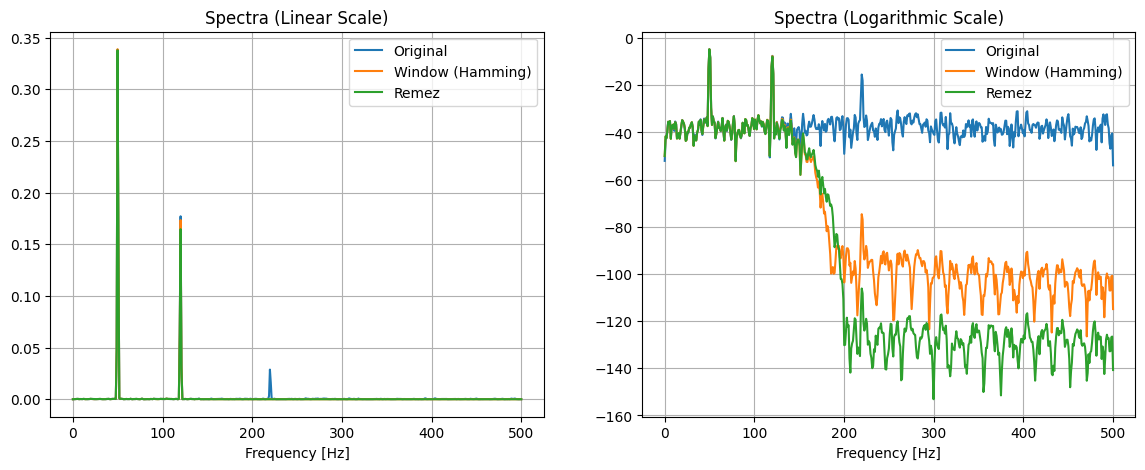

In [8]:
t_2 = np.arange(0, 2, 1/fs)
sig_24 = 1.0*np.sin(2*np.pi*50*t_2) + 0.7*np.sin(2*np.pi*120*t_2) + 0.3*np.sin(2*np.pi*220*t_2) + np.sqrt(0.1)*np.random.randn(len(t_2))

h_win_51 = signal.firwin(51, 150 / (0.5 * fs), window='hamming')
h_rem_51 = signal.remez(51, [0, 100, 200, 500], [1, 0], fs=fs)

filt_win = signal.lfilter(h_win_51, 1, sig_24)
filt_rem = signal.lfilter(h_rem_51, 1, sig_24)

f_orig, P_orig = signal.welch(sig_24, fs, nperseg=1024)
f_win, P_win = signal.welch(filt_win, fs, nperseg=1024)
f_rem, P_rem = signal.welch(filt_rem, fs, nperseg=1024)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(f_orig, P_orig, label='Original')
plt.plot(f_win, P_win, label='Window (Hamming)')
plt.plot(f_rem, P_rem, label='Remez')
plt.title('Spectra (Linear Scale)')
plt.xlabel('Frequency [Hz]')
plt.grid(True); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(f_orig, 10*np.log10(P_orig), label='Original')
plt.plot(f_win, 10*np.log10(P_win), label='Window (Hamming)')
plt.plot(f_rem, 10*np.log10(P_rem), label='Remez')
plt.title('Spectra (Logarithmic Scale)')
plt.xlabel('Frequency [Hz]')
plt.grid(True); plt.legend()
plt.show()

**Вопросы:** Какой фильтр лучше подавил 220 Гц и шум? Какой лучше сохранил 120 Гц? На сколько отличаются амплитуды 120 Гц сигнала от исходных для каждого из фильтров?


Равноволновой фильтр лучше подавляет частоту 220 Гц и высокочастотный шум, так как имеет более высокий уровень подавления в полосе заграждения при данной длине. В то же время фильтр на основе окна Хемминга лучше сохранил амплитуду на частоте 120 Гц, потому что переходная полоса у remez начинается со 100 Гц, тогда как у оконного фильтра частота среза 150 Гц. Амплитуда 120 Гц после фильтра remez занижена существенно сильнее.

## Часть 3. Синтез БИХ-фильтров

### Задание 3.1. Баттерворт, Чебышев, эллиптический – сравнение АЧХ
Спроектируйте ФНЧ с частотой среза 200 Гц (fs=1000 Гц) следующих типов (порядок 4):
- Баттерворт (`butter`);
- Чебышев I с пульсациями 1 дБ (`cheby1`);
- Чебышев II с затуханием 40 дБ в полосе заграждения (`cheby2`);
- Эллиптический с пульсациями 1 дБ и затуханием 40 дБ (`ellip`).

Постройте АЧХ всех фильтров на одном графике (в дБ). Сравните:
- крутизну среза,
- пульсации в полосе пропускания и заграждения.

Постройте и сравните фазовые характеристики (ФЧХ) и групповые задержки.


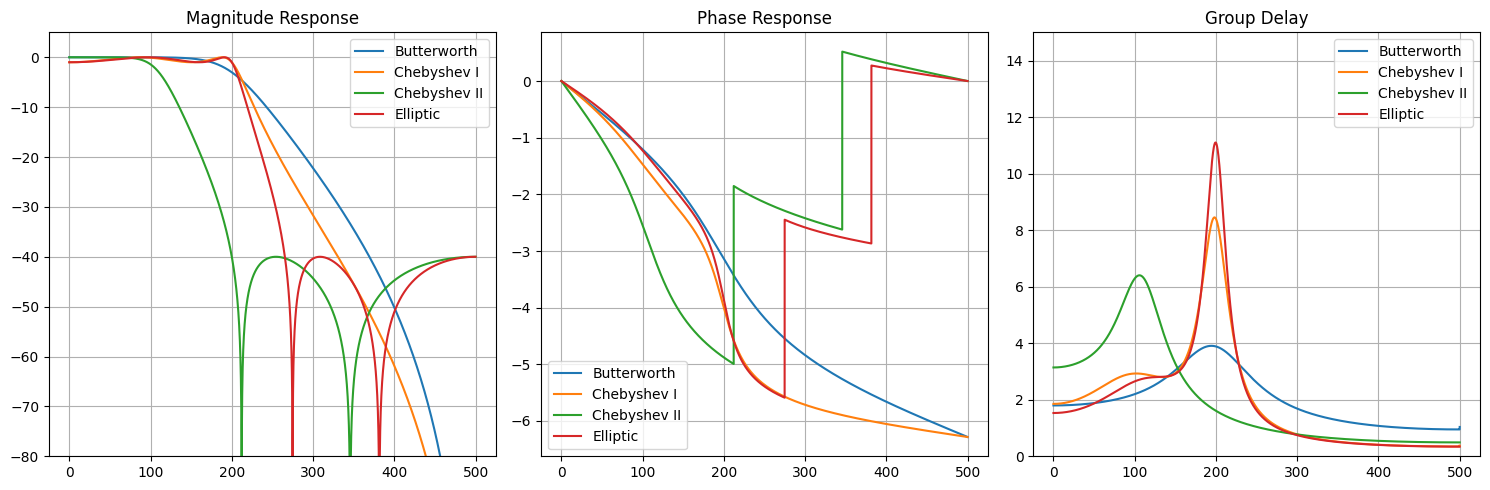

In [9]:
order = 4
Wn = 200 / (0.5 * fs)

b_but, a_but = signal.butter(order, Wn)
b_ch1, a_ch1 = signal.cheby1(order, 1, Wn)
b_ch2, a_ch2 = signal.cheby2(order, 40, Wn)
b_ell, a_ell = signal.ellip(order, 1, 40, Wn)

filters = {'Butterworth': (b_but, a_but), 'Chebyshev I': (b_ch1, a_ch1), 'Chebyshev II': (b_ch2, a_ch2), 'Elliptic': (b_ell, a_ell)}

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
for name, (b, a) in filters.items():
    w, h = signal.freqz(b, a, worN=8000)
    plt.plot(w * 0.5 * fs / np.pi, 20 * np.log10(np.abs(h) + 1e-12), label=name)
plt.title('Magnitude Response')
plt.ylim([-80, 5]); plt.grid(True); plt.legend()

plt.subplot(1, 3, 2)
for name, (b, a) in filters.items():
    w, h = signal.freqz(b, a, worN=8000)
    plt.plot(w * 0.5 * fs / np.pi, np.unwrap(np.angle(h)), label=name)
plt.title('Phase Response')
plt.grid(True); plt.legend()

plt.subplot(1, 3, 3)
for name, (b, a) in filters.items():
    w, gd = signal.group_delay((b, a), w=8000)
    plt.plot(w * 0.5 * fs / np.pi, gd, label=name)
plt.title('Group Delay')
plt.ylim([0, 15]); plt.grid(True); plt.legend()

plt.tight_layout()
plt.show()

**Вопросы:** Какой фильтр даёт самый крутой спад? Какой имеет наименьшие фазовые искажения в полосе пропускания?


Самый крутой спад (самая узкая переходная полоса) обеспечивается эллиптическим фильтром. Наименьшие фазовые искажения (наиболее ровная групповая задержка и почти линейная ФЧХ) в полосе пропускания имеет фильтр Баттерворта.

### Задание 3.2. Влияние порядка на характеристики БИХ-фильтра
Для фильтра Баттерворта с fc=200 Гц, fs=1000 Гц возьмите порядки 2, 4, 6. Постройте АЧХ и групповую задержку.


/tmp/ipykernel_10732/573355072.py:16: UserWarning: The filter's denominator is extremely small at frequencies [3.136, 3.136, 3.136, 3.137, 3.137, 3.138, 3.138, 3.138, 3.139, 3.139, 3.140, 3.140, 3.140, 3.141, 3.141], around which a singularity may be present
  w, gd = signal.group_delay((b, a), w=8000)


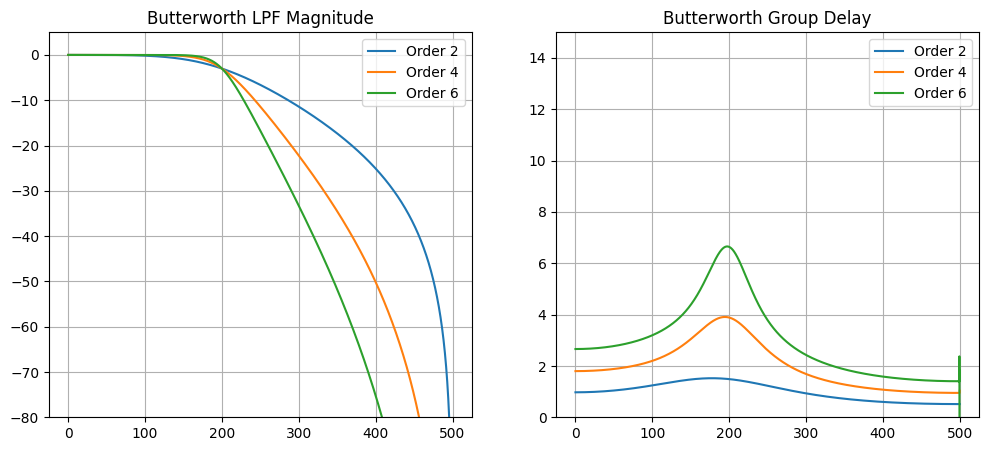

In [10]:
orders = [2, 4, 6]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for order in orders:
    b, a = signal.butter(order, 200 / (0.5 * fs))
    w, h = signal.freqz(b, a, worN=8000)
    plt.plot(w * 0.5 * fs / np.pi, 20 * np.log10(np.abs(h)), label=f'Order {order}')
plt.title('Butterworth LPF Magnitude')
plt.ylim([-80, 5]); plt.grid(True); plt.legend()

plt.subplot(1, 2, 2)
for order in orders:
    b, a = signal.butter(order, 200 / (0.5 * fs))
    w, gd = signal.group_delay((b, a), w=8000)
    plt.plot(w * 0.5 * fs / np.pi, gd, label=f'Order {order}')
plt.title('Butterworth Group Delay')
plt.ylim([0, 15]); plt.grid(True); plt.legend()

plt.show()

**Вопросы:** Как увеличение порядка влияет на крутизну среза и на групповую задержку в полосе пропускания?

Увеличение порядка фильтра Баттерворта приводит к увеличению крутизны среза АЧХ (более быстрое затухание в переходной полосе). Однако при этом возрастает максимальное значение и неравномерность групповой задержки, особенно вблизи частоты среза (усиливаются фазовые искажения).

### Задание 3.3. Преобразование типа БИХ-фильтра (ФНЧ → ФВЧ, полосовой)
Спроектируйте Баттерворта 4-го порядка:
- ФНЧ с fc=200 Гц;
- ФВЧ с fc=200 Гц (используйте `btype='high'`);
- полосовой с полосой 200–300 Гц.

Подайте на них сигнал: сумма синусоид 100, 250, 400 Гц. Постройте спектры после фильтрации.


/tmp/ipykernel_10732/4110956954.py:16: UserWarning: nperseg=1024 is greater than signal length max(len(x), len(y)) = 1000, using nperseg = 1000
  f, P_lp = signal.welch(filt_lp, 1000, nperseg=1024)
/tmp/ipykernel_10732/4110956954.py:17: UserWarning: nperseg=1024 is greater than signal length max(len(x), len(y)) = 1000, using nperseg = 1000
  f, P_hp = signal.welch(filt_hp, 1000, nperseg=1024)
/tmp/ipykernel_10732/4110956954.py:18: UserWarning: nperseg=1024 is greater than signal length max(len(x), len(y)) = 1000, using nperseg = 1000
  f, P_bp = signal.welch(filt_bp, 1000, nperseg=1024)


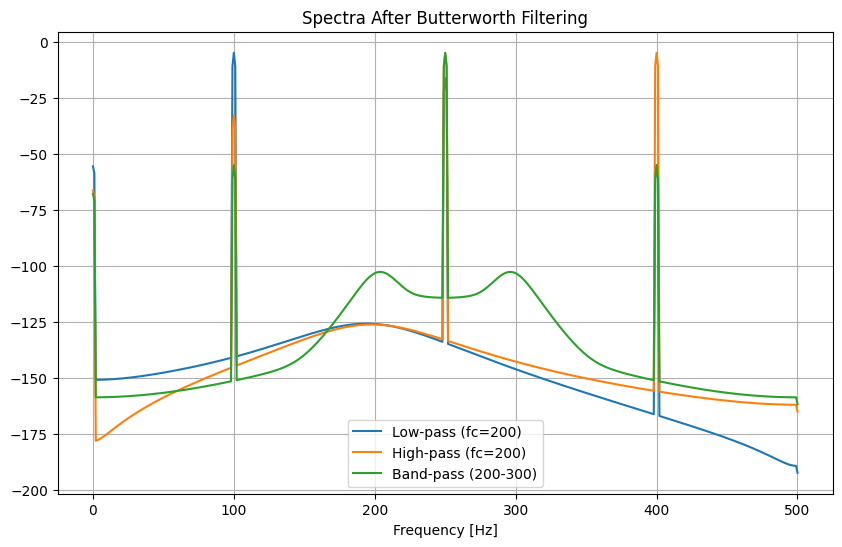

In [11]:
order = 4
nyq = 0.5 * 1000

b_lp, a_lp = signal.butter(order, 200 / nyq, btype='low')
b_hp, a_hp = signal.butter(order, 200 / nyq, btype='high')
b_bp, a_bp = signal.butter(order, [200 / nyq, 300 / nyq], btype='bandpass')

t_3 = np.arange(0, 1, 1/1000)
sig_3 = np.sin(2 * np.pi * 100 * t_3) + np.sin(2 * np.pi * 250 * t_3) + np.sin(2 * np.pi * 400 * t_3)

filt_lp = signal.lfilter(b_lp, a_lp, sig_3)
filt_hp = signal.lfilter(b_hp, a_hp, sig_3)
filt_bp = signal.lfilter(b_bp, a_bp, sig_3)

plt.figure(figsize=(10, 6))
f, P_lp = signal.welch(filt_lp, 1000, nperseg=1024)
f, P_hp = signal.welch(filt_hp, 1000, nperseg=1024)
f, P_bp = signal.welch(filt_bp, 1000, nperseg=1024)

plt.plot(f, 10 * np.log10(P_lp), label='Low-pass (fc=200)')
plt.plot(f, 10 * np.log10(P_hp), label='High-pass (fc=200)')
plt.plot(f, 10 * np.log10(P_bp), label='Band-pass (200-300)')
plt.title('Spectra After Butterworth Filtering')
plt.xlabel('Frequency [Hz]')
plt.grid(True); plt.legend()
plt.show()

**Вопрос:** Какие составляющие подавлены, а какие пропущены в каждом случае?

- ФНЧ (срез 200 Гц) пропускает компоненту 100 Гц и подавляет 250 Гц и 400 Гц.
- ФВЧ (срез 200 Гц) подавляет 100 Гц и пропускает 250 Гц и 400 Гц.
- Полосовой фильтр (200–300 Гц) подавляет 100 Гц и 400 Гц, но пропускает частоту 250 Гц.

### Задание 3.4. Применение БИХ-фильтра к зашумлённому сигналу
Сгенерируйте сигнал: синусоида 50 Гц + белый шум с дисперсией 0.2, fs=1000 Гц, длительность 1 с. Спроектируйте эллиптический ФНЧ с fc=100 Гц (порядок 6, пульсации 1 дБ, затухание 40 дБ). Примените фильтр с помощью `lfilter` и `filtfilt`. Постройте на одном графике исходный и отфильтрованные сигналы (временные области, первые 0.2 с), а также их спектры. Сравните задержку и подавление шума.


/tmp/ipykernel_10732/1183104996.py:20: UserWarning: nperseg=1024 is greater than signal length max(len(x), len(y)) = 1000, using nperseg = 1000
  f, P_orig = signal.welch(sig_4, 1000, nperseg=1024)
/tmp/ipykernel_10732/1183104996.py:21: UserWarning: nperseg=1024 is greater than signal length max(len(x), len(y)) = 1000, using nperseg = 1000
  f, P_lfil = signal.welch(filt_lfilter, 1000, nperseg=1024)
/tmp/ipykernel_10732/1183104996.py:22: UserWarning: nperseg=1024 is greater than signal length max(len(x), len(y)) = 1000, using nperseg = 1000
  f, P_ffil = signal.welch(filt_filtfilt, 1000, nperseg=1024)


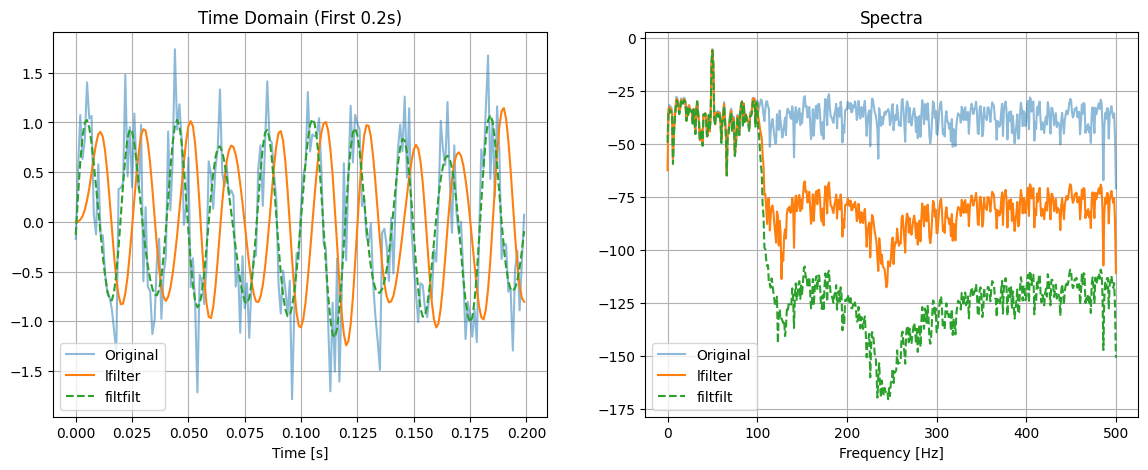

In [12]:
t_4 = np.arange(0, 1, 1/1000)
sig_4 = np.sin(2 * np.pi * 50 * t_4) + np.sqrt(0.2) * np.random.randn(len(t_4))

b_ell, a_ell = signal.ellip(6, 1, 40, 100 / (0.5 * 1000))

filt_lfilter = signal.lfilter(b_ell, a_ell, sig_4)
filt_filtfilt = signal.filtfilt(b_ell, a_ell, sig_4)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
idx = int(0.2 * 1000)
plt.plot(t_4[:idx], sig_4[:idx], label='Original', alpha=0.5)
plt.plot(t_4[:idx], filt_lfilter[:idx], label='lfilter')
plt.plot(t_4[:idx], filt_filtfilt[:idx], label='filtfilt', linestyle='--')
plt.title('Time Domain (First 0.2s)')
plt.xlabel('Time [s]')
plt.grid(True); plt.legend()

plt.subplot(1, 2, 2)
f, P_orig = signal.welch(sig_4, 1000, nperseg=1024)
f, P_lfil = signal.welch(filt_lfilter, 1000, nperseg=1024)
f, P_ffil = signal.welch(filt_filtfilt, 1000, nperseg=1024)

plt.plot(f, 10 * np.log10(P_orig), label='Original', alpha=0.5)
plt.plot(f, 10 * np.log10(P_lfil), label='lfilter')
plt.plot(f, 10 * np.log10(P_ffil), label='filtfilt', linestyle='--')
plt.title('Spectra')
plt.xlabel('Frequency [Hz]')
plt.grid(True); plt.legend()
plt.show()

**Вопрос:** Почему `filtfilt` даёт нулевой фазовый сдвиг?

Функция `filtfilt` выполняет фильтрацию дважды: сначала в прямом направлении, а затем в обратном. Фазовый сдвиг (задержка), вносимый фильтром при прямом проходе, в точности компенсируется при обратном проходе. В результате общий фазовый сдвиг становится равным нулю, и сигнал не испытывает задержки.

## Часть 4. Сравнение КИХ и БИХ фильтров одинакового порядка

### Задание 4.1. Сравнение характеристик
Спроектируйте:
- КИХ-ФНЧ методом окон (окно Хемминга, длина 51, fc=200 Гц);
- БИХ-ФНЧ Баттерворта 4-го порядка (fc=200 Гц).

Постройте для них на одном графике:
- отдельно АЧХ (в дБ),
- отдельно групповую задержку.


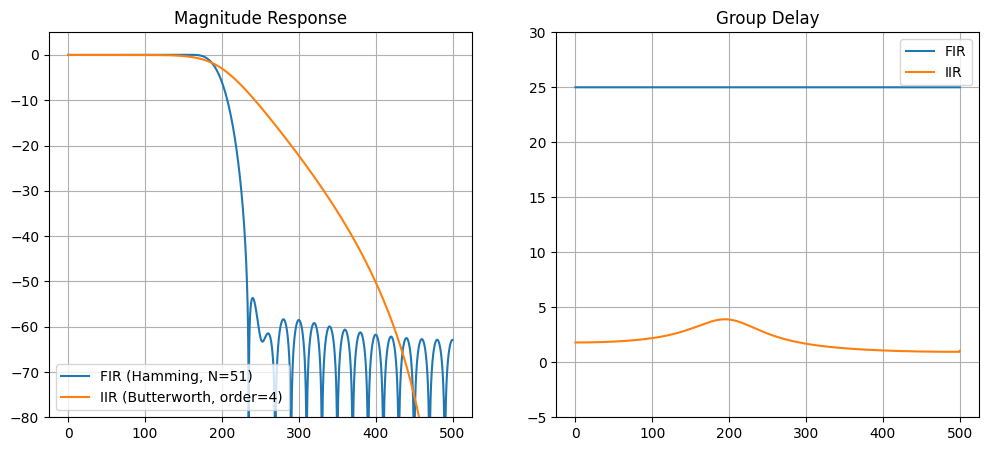

In [13]:
h_fir_4 = signal.firwin(51, 200 / 500, window='hamming')
b_iir_4, a_iir_4 = signal.butter(4, 200 / 500)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
w, H_fir = signal.freqz(h_fir_4, worN=8000)
w, H_iir = signal.freqz(b_iir_4, a_iir_4, worN=8000)
freqs_4 = w * 500 / np.pi
plt.plot(freqs_4, 20 * np.log10(np.abs(H_fir) + 1e-12), label='FIR (Hamming, N=51)')
plt.plot(freqs_4, 20 * np.log10(np.abs(H_iir) + 1e-12), label='IIR (Butterworth, order=4)')
plt.title('Magnitude Response')
plt.ylim([-80, 5]); plt.grid(True); plt.legend()

plt.subplot(1, 2, 2)
w, gd_fir = signal.group_delay((h_fir_4, 1), w=8000)
w, gd_iir = signal.group_delay((b_iir_4, a_iir_4), w=8000)
plt.plot(freqs_4, gd_fir, label='FIR')
plt.plot(freqs_4, gd_iir, label='IIR')
plt.title('Group Delay')
plt.ylim([-5, 30]); plt.grid(True); plt.legend()

plt.show()

**Вопросы:** Какой фильтр имеет более крутой срез? Какой имеет постоянную групповую задержку? Какой вносит меньшие фазовые искажения? Какой требует меньше вычислений? Попробуйте увеличить порядок фильтра Баттерворта. При каком порядке крутизна среза его АЧХ становится сравнимой с КИХ-фильтром? Растут или уменьшаются при этом фазовые искажения?


КИХ-фильтр имеет более крутой срез по сравнению с БИХ-фильтром 4-го порядка. КИХ-фильтр обладает строго постоянной групповой задержкой и вносит меньшие фазовые искажения. БИХ-фильтр 4 порядка требует меньше вычислений. Если увеличивать порядок фильтра Баттерворта, то крутизна его среза становится сравнимой с КИХ-фильтром (51 отсчет) при порядках около 8-10. При этом фазовые искажения БИХ-фильтра значительно растут.

### Задание 4.2. Применение к реальному сигналу
Сгенерируйте сигнал: короткий прямоугольный импульс длительностью 10 мс, а также высокочастотная синусоидальная помеха 400 Гц. Частоту дискретизации возьмите fs=10000 Гц.

Примените оба фильтра (КИХ и БИХ из предыдущего пункта). Постройте исходный и отфильтрованные сигналы.


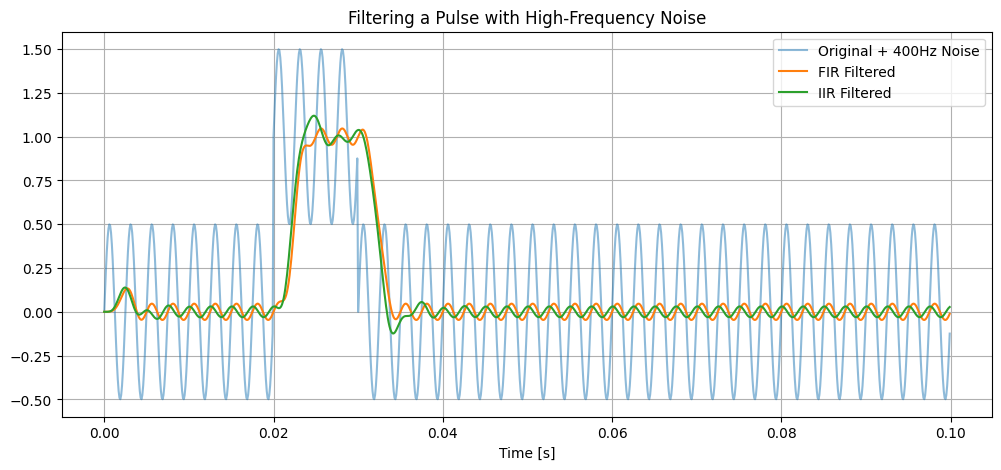

In [14]:
fs_10k = 10000
t_10k = np.arange(0, 0.1, 1/fs_10k)
pulse = np.zeros_like(t_10k)
pulse[int(0.02 * fs_10k):int(0.03 * fs_10k)] = 1.0
noise = 0.5 * np.sin(2 * np.pi * 400 * t_10k)
sig_10k = pulse + noise

h_fir_10k = signal.firwin(51, 200 / (0.5 * fs_10k), window='hamming')
b_iir_10k, a_iir_10k = signal.butter(4, 200 / (0.5 * fs_10k))

filt_fir_10k = signal.lfilter(h_fir_10k, 1, sig_10k)
filt_iir_10k = signal.lfilter(b_iir_10k, a_iir_10k, sig_10k)

plt.figure(figsize=(12, 5))
plt.plot(t_10k, sig_10k, label='Original + 400Hz Noise', alpha=0.5)
plt.plot(t_10k, filt_fir_10k, label='FIR Filtered')
plt.plot(t_10k, filt_iir_10k, label='IIR Filtered')
plt.title('Filtering a Pulse with High-Frequency Noise')
plt.xlabel('Time [s]')
plt.grid(True); plt.legend()
plt.show()

**Вопросы:** Какой фильтр лучше сохранил форму импульсов? Какой лучше подавил помеху?

КИХ-фильтр лучше сохранил симметричную форму импульса благодаря линейной ФЧХ. БИХ-фильтр исказил фронты импульса (затянул задний фронт из-за нелинейной ФЧХ). Оба фильтра хорошо подавили помеху 400 Гц, однако БИХ-фильтр при данных параметрах имеет сильные фазовые задержки, что критично для импульсных сигналов.